# Detector Timing Analysis

This notebook analyzes time-resolved collision tracking data from a fixed-source simulation with a separated detector. Key analyses include:

- **Time-binned histograms**: Logarithmic binning to capture multi-decade time distributions
- **Sibling multiplicity**: Distribution of neutrons detected from the same parent particle
- **Validation**: Checking that first detections are physically possible
- **Fission statistics**: Extracting fission counts from tally data
- **Rossi alpha**: Autocorrelation histogram for extracting the decay constant α

## Setup and Imports

In [13]:
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import openmc
import pandas as pd
import scienceplots

from project.core.geometry import DEFAULTS

# Configure plotting style
plt.style.use(["science", "notebook", "grid", "high-vis"])

# Output directories
FIGURES_DIR = Path("../outputs/figures")
DATA_DIR = Path("../outputs/data")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load Collision Track Data

Load the collision track HDF5 file and convert to a pandas DataFrame for analysis.

In [14]:
# Load collision track file
collision_file = Path("../../results/simulation_with_detector/collision_track.h5")
data: Any = openmc.read_collision_track_file(str(collision_file))

# Convert to DataFrame
df = pd.DataFrame(
    {
        "r_x": data["r"]["x"],
        "r_y": data["r"]["y"],
        "r_z": data["r"]["z"],
        "u_x": data["u"]["x"],
        "u_y": data["u"]["y"],
        "u_z": data["u"]["z"],
        "E": data["E"],
        "dE": data["dE"],
        "time": data["time"],
        "wgt": data["wgt"],
        "event_mt": data["event_mt"],
        "delayed_group": data["delayed_group"],
        "cell_id": data["cell_id"],
        "nuclide_id": data["nuclide_id"],
        "material_id": data["material_id"],
        "universe_id": data["universe_id"],
        "n_collision": data["n_collision"],
        "particle": data["particle"],
        "parent_id": data["parent_id"],
        "progeny_id": data["progeny_id"],
    }
)

print(f"Total collision events: {len(df):,}")
df.head()

Total collision events: 355,899


,r_x,r_y,r_z,u_x,u_y,u_z,E,dE,time,wgt,event_mt,delayed_group,cell_id,nuclide_id,material_id,universe_id,n_collision,particle,parent_id,progeny_id
0,1.831121,13.353877,-0.245995,0.064518,0.997635,-0.023682,3.631516,0.0,0.000053,0.0,101,0,2,50100,2,1,29,0,700004,22
1,1.618520,13.867317,-2.302455,0.090656,0.981874,-0.166446,0.007879,0.0,0.000108,0.0,101,0,2,50100,2,1,34,0,950006,2
2,0.309100,13.022297,-0.356256,0.011483,0.999514,0.028984,0.033797,0.0,0.000075,0.0,101,0,2,50100,2,1,26,0,150010,30
3,-1.771859,13.770436,1.991201,-0.267507,0.963411,0.016698,7988.348747,0.0,0.000005,0.0,101,0,2,50100,2,1,7,0,150016,2
4,-3.573732,15.026659,1.840563,-0.115868,0.987284,0.108835,0.130385,0.0,0.000212,0.0,101,0,2,50100,2,1,18,0,50019,124


In [15]:
# Extract detector collision times (cell_id == 2 is the detector)
DETECTOR_CELL_ID = 2
detector_times = df[df["cell_id"] == DETECTOR_CELL_ID]["time"].values

print(f"Detector collisions: {len(detector_times):,}")
print(f"Time range: {detector_times.min():.2e} - {detector_times.max():.2e} s")

Detector collisions: 355,899
Time range: 6.00e-09 - 6.22e+02 s


## Time-Binned Histogram Analysis

Create logarithmically-spaced bins to capture the multi-decade time distribution of detector events.

In [16]:
# Prepare data: remove non-positive and non-finite values
times_clean = detector_times[np.isfinite(detector_times) & (detector_times > 0)]

if times_clean.size == 0:
    raise ValueError("No valid positive timestamps found for histogram")

# Create logarithmic bins
N_BINS = 256
log_edges = np.logspace(
    np.log10(times_clean.min()), np.log10(times_clean.max()), N_BINS + 1
)

# Compute histogram
counts, edges = np.histogram(times_clean, bins=log_edges)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = edges[1:] - edges[:-1]

# Store in DataFrame for analysis and export
hist_df = pd.DataFrame(
    {
        "count": counts,
        "density": counts / bin_widths,
        "left_edge": edges[:-1],
        "right_edge": edges[1:],
        "center": bin_centers,
        "width": bin_widths,
    }
)

print(f"Created {N_BINS} logarithmic bins")
hist_df.head()

Created 256 logarithmic bins


,count,density,left_edge,right_edge,center,width
0,40,6.403898e+10,5.996968e-09,6.621587e-09,6.309278e-09,6.246195e-10
1,39,5.654818e+10,6.621587e-09,7.311265e-09,6.966426e-09,6.896773e-10
2,47,6.171937e+10,7.311265e-09,8.072776e-09,7.692020e-09,7.615113e-10
3,37,4.400429e+10,8.072776e-09,8.913603e-09,8.493190e-09,8.408272e-10
4,20,2.154234e+10,8.913603e-09,9.842007e-09,9.377805e-09,9.284043e-10


### Visualize Time Distributions

Plot histograms with different scale combinations to reveal structure at different timescales.

In [17]:
def plot_histogram(centers, values, widths, xscale, yscale, ylabel, title, filename):
    """Helper function to create consistent histogram plots."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)
    ax.bar(centers, values, width=widths, align="center", edgecolor="k", alpha=0.8)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    return fig, ax

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Detector Arrival Times (Log-Linear)'}, xlabel='Time (s)', ylabel='Counts'>)

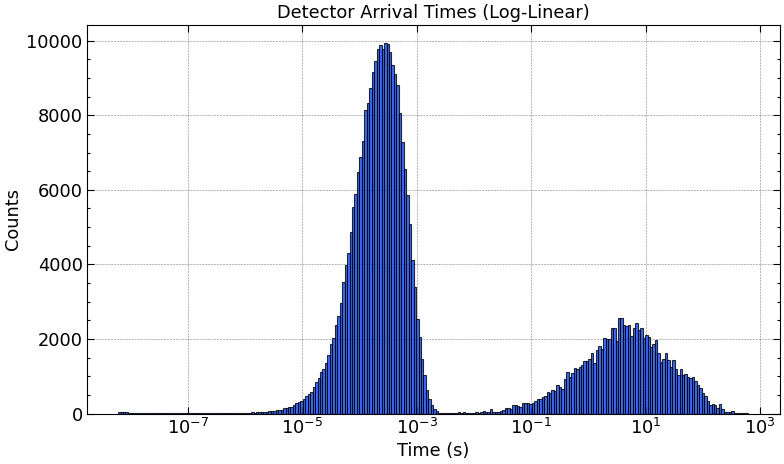

In [18]:
# Count histogram: log-linear
plot_histogram(
    bin_centers,
    counts,
    bin_widths,
    xscale="log",
    yscale="linear",
    ylabel="Counts",
    title="Detector Arrival Times (Log-Linear)",
    filename="detector_histogram_log_linear.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Detector Arrival Times (Log-Log)'}, xlabel='Time (s)', ylabel='Counts'>)

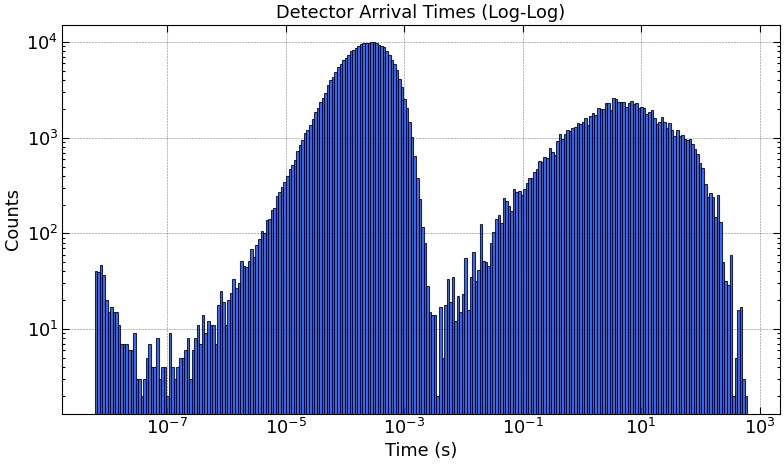

In [19]:
# Count histogram: log-log
plot_histogram(
    bin_centers,
    counts,
    bin_widths,
    xscale="log",
    yscale="log",
    ylabel="Counts",
    title="Detector Arrival Times (Log-Log)",
    filename="detector_histogram_log_log.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Detector Arrival Rate (Log-Linear)'}, xlabel='Time (s)', ylabel='Counts per Unit Time'>)

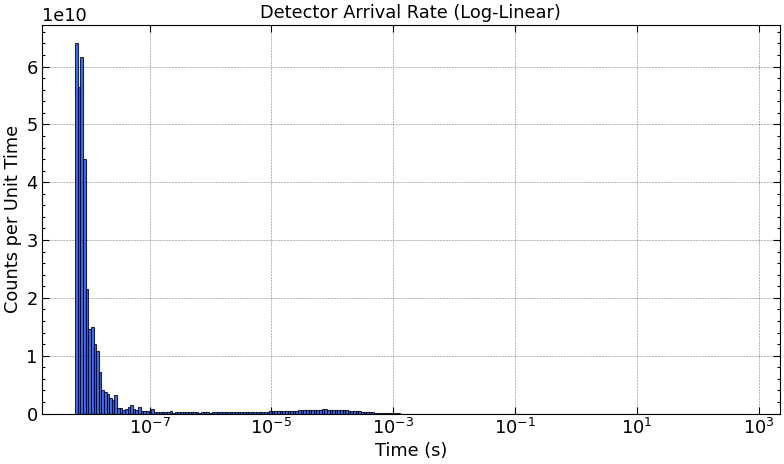

In [20]:
# Density histogram: log-linear
plot_histogram(
    bin_centers,
    counts / bin_widths,
    bin_widths,
    xscale="log",
    yscale="linear",
    ylabel="Counts per Unit Time",
    title="Detector Arrival Rate (Log-Linear)",
    filename="detector_density_histogram_log_linear.png",
)

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Detector Arrival Rate (Log-Log)'}, xlabel='Time (s)', ylabel='Counts per Unit Time'>)

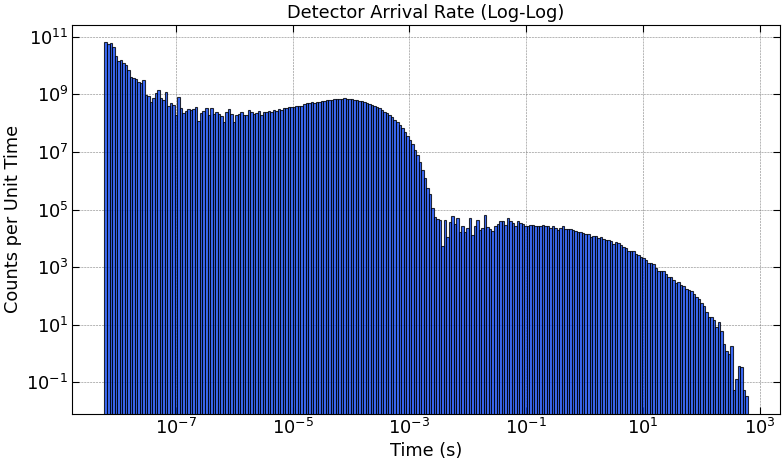

In [21]:
# Density histogram: log-log
plot_histogram(
    bin_centers,
    counts / bin_widths,
    bin_widths,
    xscale="log",
    yscale="log",
    ylabel="Counts per Unit Time",
    title="Detector Arrival Rate (Log-Log)",
    filename="detector_density_histogram_log_log.png",
)


### Cumulative Detection Integral

Cumulative sum of detected neutrons over time — the discrete integral of the arrival rate.
Each point shows the total number of detections up to that time.
Log–log reveals power-law accumulation regimes; the linear-y panel shows saturation.

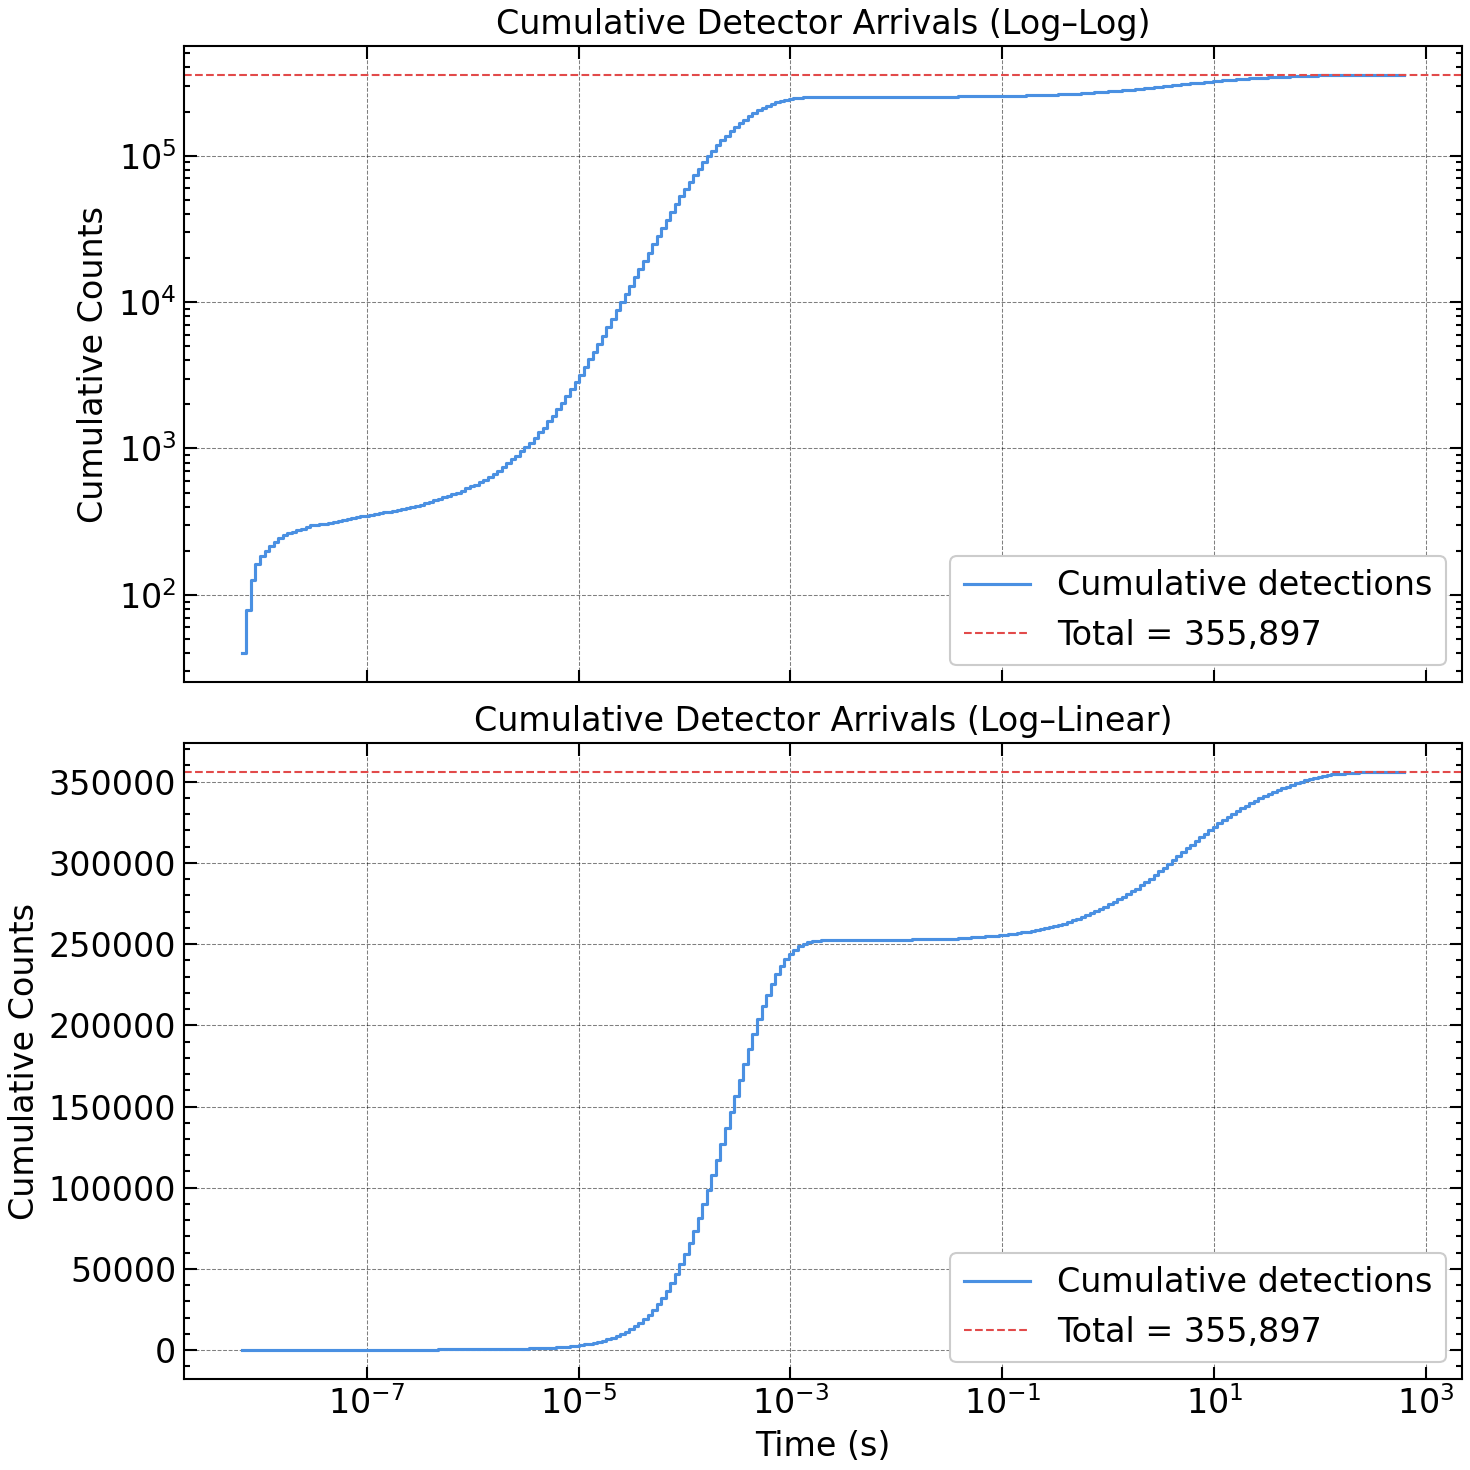

50% of detections by: 3.957e-04 s
90% of detections by: 9.693e+00 s


In [22]:
# Cumulative integral of the arrival rate: sum(density * bin_width) = sum(counts)
cumulative_counts = np.cumsum(counts)
x_cumulative = hist_df["right_edge"].values  # right-edge is CDF-correct
total_detections = int(cumulative_counts[-1])

fig, (ax_log, ax_lin) = plt.subplots(2, 1, figsize=(10, 10), dpi=150, sharex=True)

for ax, yscale in zip([ax_log, ax_lin], ["log", "linear"]):
    ax.plot(
        x_cumulative, cumulative_counts,
        color="#4A90E2", lw=1.5, drawstyle="steps-post",
        label="Cumulative detections",
    )
    ax.axhline(total_detections, color="#E24A4A", lw=1.0, ls="--",
               label=f"Total = {total_detections:,}")
    ax.set_xscale("log")
    ax.set_yscale(yscale)
    ax.set_ylabel("Cumulative Counts")
    ax.legend(frameon=True)

ax_log.set_title("Cumulative Detector Arrivals (Log–Log)")
ax_lin.set_title("Cumulative Detector Arrivals (Log–Linear)")
ax_lin.set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "detector_cumulative_integral.png", dpi=300, bbox_inches="tight")
plt.show()

idx_50 = np.searchsorted(cumulative_counts, total_detections // 2)
idx_90 = np.searchsorted(cumulative_counts, int(0.9 * total_detections))
print(f"50% of detections by: {x_cumulative[idx_50]:.3e} s")
print(f"90% of detections by: {x_cumulative[idx_90]:.3e} s")

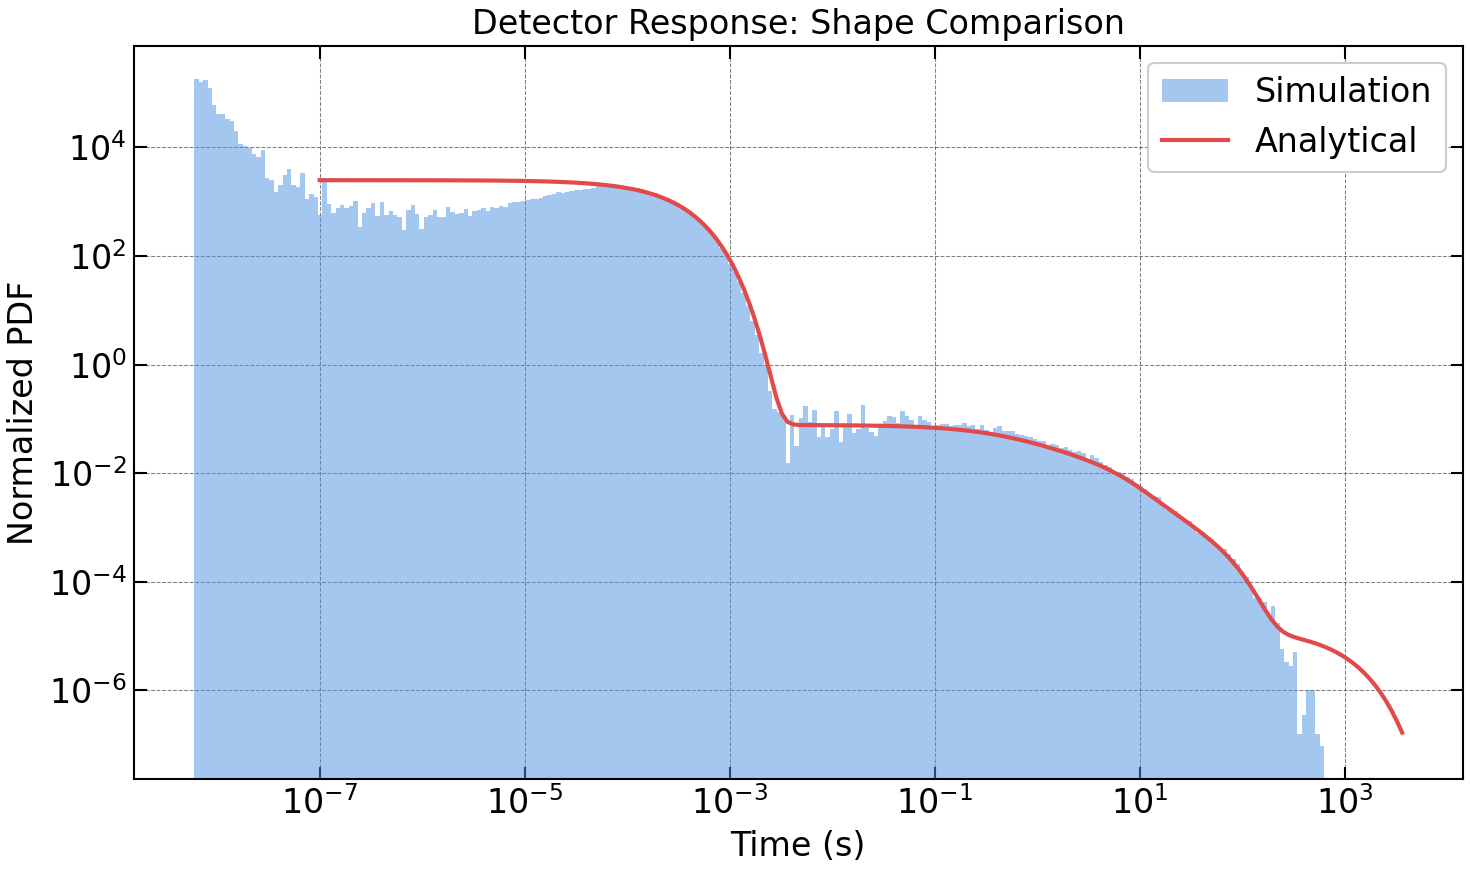

In [23]:
# Normalize both distributions to unit area for shape comparison
hist_density = counts / bin_widths
hist_pdf = hist_density / np.trapezoid(hist_density, bin_centers)

data = np.load(Path("~/projects/izhar-code").expanduser() / "detector_response.npz")
analytical_time = data["time"]
analytical_resp_density = data["detector_response"] / analytical_time
analytical_pdf = analytical_resp_density / np.trapezoid(analytical_resp_density, analytical_time)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.stairs(hist_pdf, edges, fill=True, color="#4A90E2", alpha=0.5, edgecolor="#4A90E2", label="Simulation")
ax.plot(analytical_time, analytical_pdf, color="#E24A4A", lw=2, label="Analytical")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized PDF")
ax.set_title("Detector Response: Shape Comparison")
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "detector_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Prompt Neutron Decay — Alpha Extraction

Rebin the detection times onto a linear time axis in the alpha-sensitive region (0.1–10 ms), then fit an exponential decay A·exp(−α·t) + C to extract the prompt neutron decay constant α. The constant C captures the delayed neutron floor.

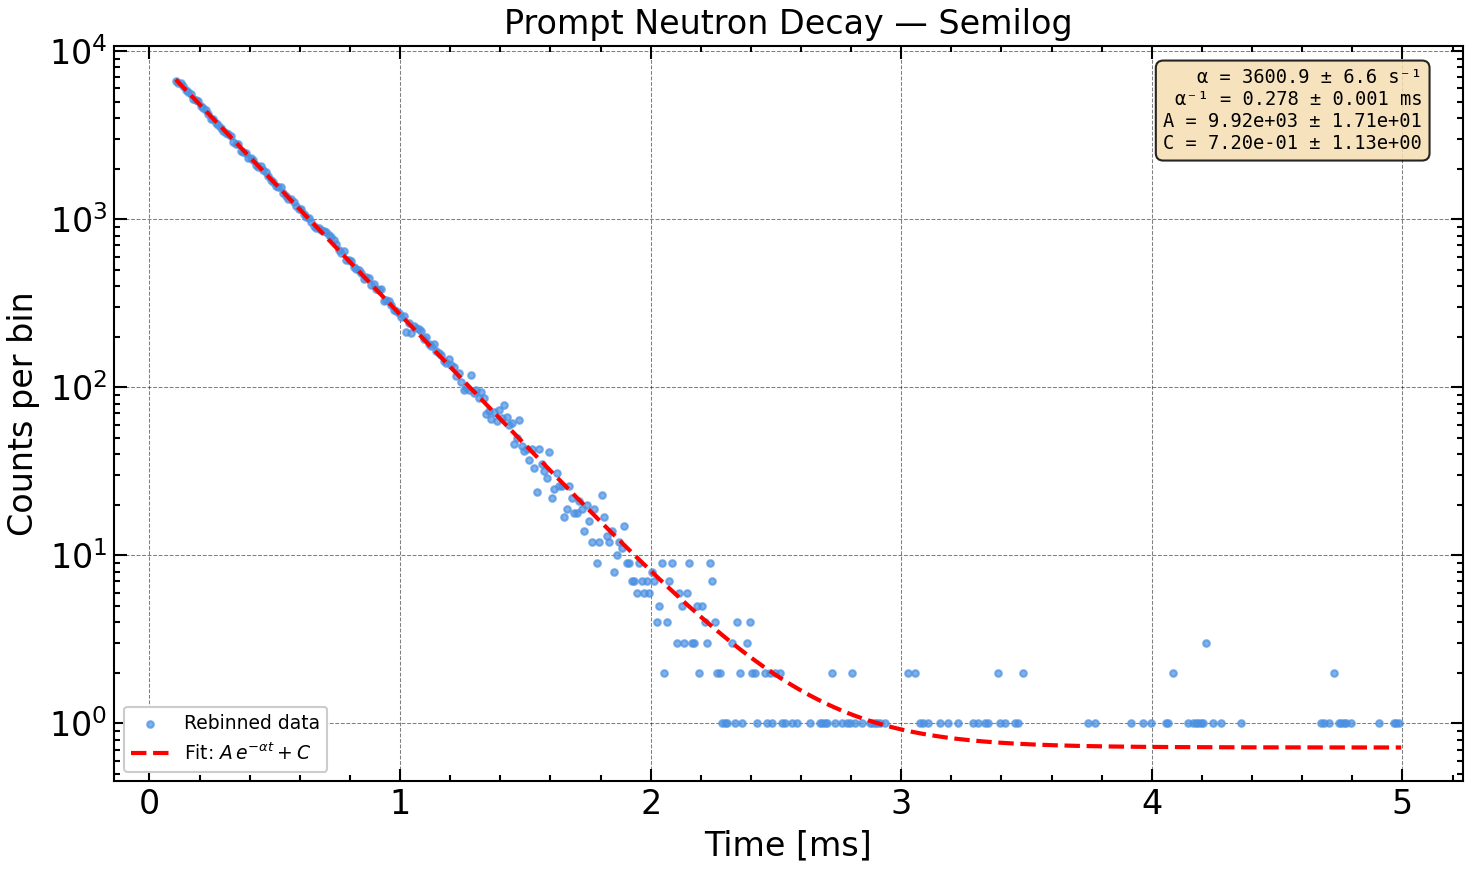

Fit results (range 0.10 – 5.00 ms):
  α           = 3,600.9 ± 6.6 s⁻¹
  α⁻¹         = 0.278 ± 0.001 ms
  A           = 9.9166e+03 ± 1.7063e+01
  C (floor)   = 7.1980e-01 ± 1.1338e+00
  Bins in fit = 490 / 490


In [24]:
from scipy.optimize import curve_fit

# ── Adjustable parameters ────────────────────────────────────────────
t_bin_min = 1e-4          # left edge of rebinning window  [s]  (0.1 ms)
t_bin_max = 5e-3          # right edge of rebinning window [s]  (10 ms)
bin_width = 10e-6          # uniform bin width              [s]  (~30 μs)

t_fit_min = t_bin_min      # left  edge of fit range [s] ← adjust & re-run
t_fit_max = t_bin_max      # right edge of fit range [s] ← adjust & re-run
# ─────────────────────────────────────────────────────────────────────

# 1. Rebin onto a linear axis (raw counts, no density normalisation)
n_linear_bins = int(np.round((t_bin_max - t_bin_min) / bin_width))
linear_edges = np.linspace(t_bin_min, t_bin_max, n_linear_bins + 1)
linear_counts, _ = np.histogram(times_clean, bins=linear_edges)
linear_centers = (linear_edges[:-1] + linear_edges[1:]) / 2

# 2. Fit mask
fit_mask = (linear_centers >= t_fit_min) & (linear_centers <= t_fit_max)
t_fit = linear_centers[fit_mask]
c_fit = linear_counts[fit_mask]


# 3. Exponential + constant model
def decay_model(t, A, alpha, C):
    return A * np.exp(-alpha * t) + C


p0 = [c_fit.max(), 1000.0, c_fit.min()]
popt, pcov = curve_fit(decay_model, t_fit, c_fit, p0=p0, maxfev=20000)
A_fit, alpha_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))
A_err, alpha_err, C_err = perr

# 4. Smooth fit curve for plotting
t_smooth = np.linspace(linear_centers[0], linear_centers[-1], 500)

# ── Semilog plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.scatter(
    linear_centers * 1e3,
    linear_counts,
    s=10,
    color="#4A90E2",
    alpha=0.7,
    label="Rebinned data",
    zorder=2,
)
ax.plot(
    t_smooth * 1e3,
    decay_model(t_smooth, *popt),
    "r--",
    lw=2,
    label=r"Fit: $A\,e^{-\alpha t} + C$",
    zorder=3,
)
# Shade the fit range if it differs from the full range
if t_fit_min > t_bin_min or t_fit_max < t_bin_max:
    ax.axvspan(t_fit_min * 1e3, t_fit_max * 1e3, color="red", alpha=0.06, label="Fit range")
ax.set_yscale("log")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Counts per bin")
ax.set_title("Prompt Neutron Decay — Semilog")
ax.legend(frameon=True, fontsize=9)

# Annotate parameters
param_text = (
    f"α = {alpha_fit:.1f} ± {alpha_err:.1f} s⁻¹\n"
    f"α⁻¹ = {1e3/alpha_fit:.3f} ± {1e3*alpha_err/alpha_fit**2:.3f} ms\n"
    f"A = {A_fit:.2e} ± {A_err:.2e}\n"
    f"C = {C_fit:.2e} ± {C_err:.2e}"
)
ax.text(
    0.97,
    0.97,
    param_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.85),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "prompt_decay_fit.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Fit results (range {t_fit_min*1e3:.2f} – {t_fit_max*1e3:.2f} ms):")
print(f"  α           = {alpha_fit:,.1f} ± {alpha_err:.1f} s⁻¹")
print(f"  α⁻¹         = {1e3/alpha_fit:.3f} ± {1e3*alpha_err/alpha_fit**2:.3f} ms")
print(f"  A           = {A_fit:.4e} ± {A_err:.4e}")
print(f"  C (floor)   = {C_fit:.4e} ± {C_err:.4e}")
print(f"  Bins in fit = {fit_mask.sum()} / {len(linear_counts)}")

### Export Binned Data

In [25]:
# Export histogram data to Excel
output_file = DATA_DIR / "collision_track_binned.xlsx"
hist_df.to_excel(output_file, index=False)
print(f"Saved {len(hist_df)} bins to {output_file}")

Saved 256 bins to ../outputs/data/collision_track_binned.xlsx


## Sibling Multiplicity Analysis

Analyze how many neutrons from the same parent particle reach the detector. This reveals correlations in the neutron transport process.

In [26]:
def calculate_sibling_multiplicity(parent_ids):
    """
    Calculate the distribution of detection multiplicities per parent particle.

    Parameters
    ----------
    parent_ids : array-like
        Parent ID for each detected neutron

    Returns
    -------
    multiplicities : np.ndarray
        Array [1, 2, 3, ...] up to max observed
    counts : np.ndarray
        How many parents had each multiplicity
    stats : dict
        Summary statistics
    """
    # Count detections per parent
    detections_per_parent = Counter(parent_ids)

    # Count parents with each multiplicity
    multiplicity_dist = Counter(detections_per_parent.values())

    # Create arrays
    max_multiplicity = max(multiplicity_dist.keys())
    multiplicities = np.arange(1, max_multiplicity + 1)
    counts = np.array([multiplicity_dist.get(m, 0) for m in multiplicities])

    # Calculate statistics
    total_parents = counts.sum()
    total_detections = (multiplicities * counts).sum()
    mean_multiplicity = total_detections / total_parents if total_parents > 0 else 0

    stats = {
        "total_parents": int(total_parents),
        "total_detections": int(total_detections),
        "mean_multiplicity": float(mean_multiplicity),
        "max_multiplicity": int(max_multiplicity),
    }

    return multiplicities, counts, stats

In [27]:
# Extract parent IDs for detector events
detector_parent_ids = df[df["cell_id"] == DETECTOR_CELL_ID]["parent_id"].values

# Calculate sibling multiplicity
multiplicities, mult_counts, mult_stats = calculate_sibling_multiplicity(
    detector_parent_ids
)

print("\nSibling Multiplicity Statistics:")
print(f"  Total parent particles: {mult_stats['total_parents']:,}")
print(f"  Total detections: {mult_stats['total_detections']:,}")
print(f"  Mean multiplicity: {mult_stats['mean_multiplicity']:.3f}")
print(f"  Max multiplicity: {mult_stats['max_multiplicity']}")


Sibling Multiplicity Statistics:
  Total parent particles: 99,744
  Total detections: 355,899
  Mean multiplicity: 3.568
  Max multiplicity: 170


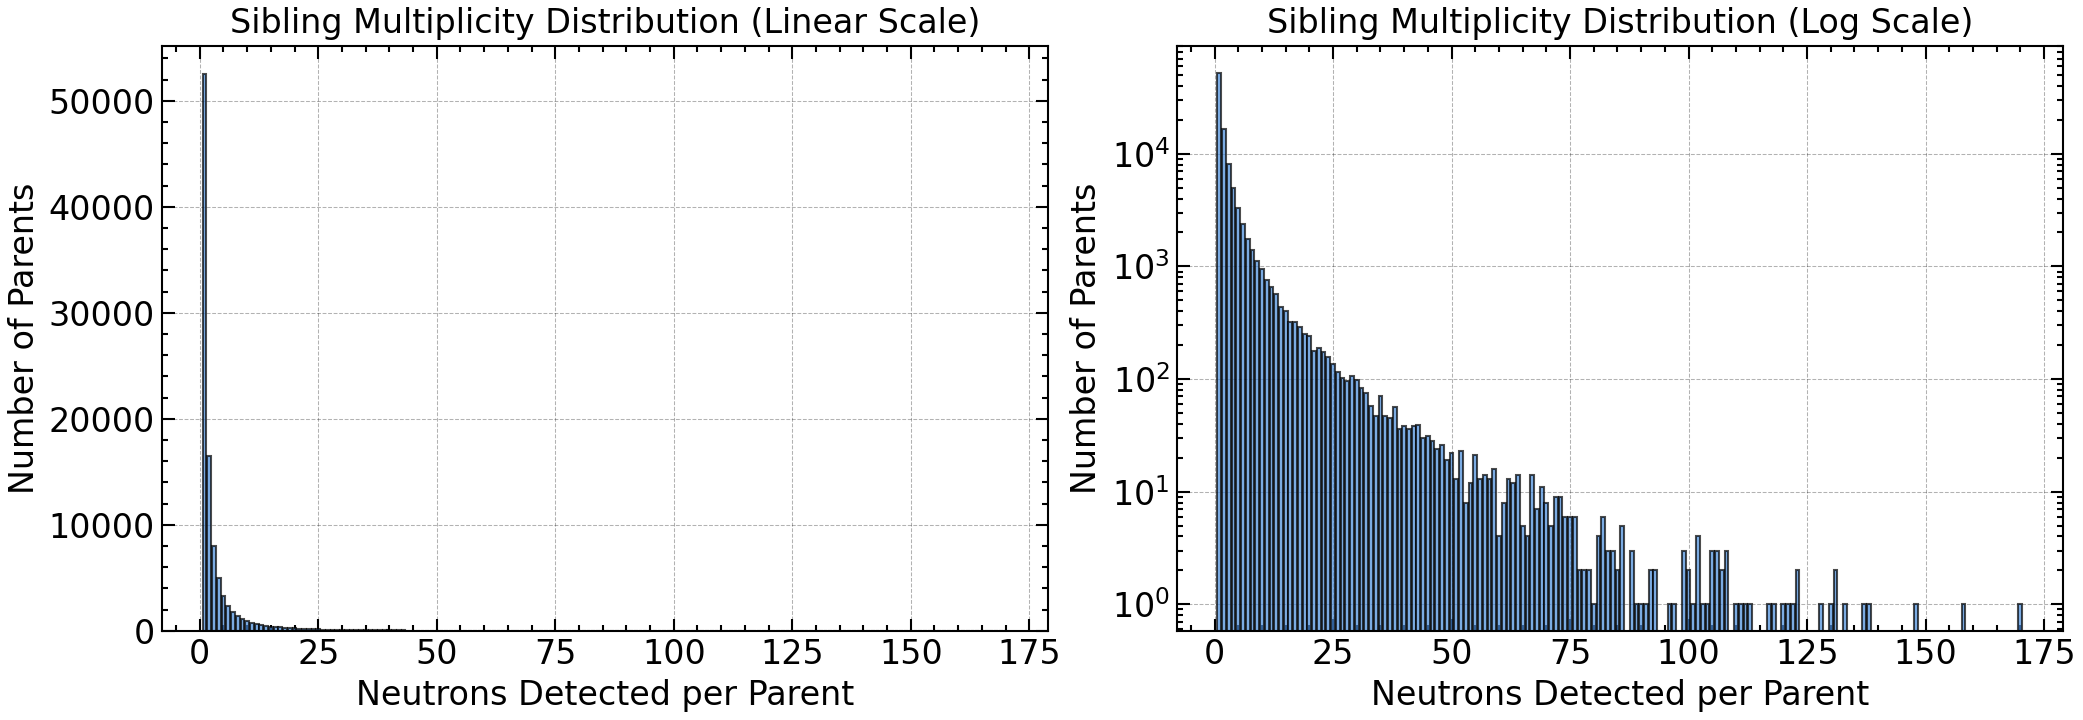

In [28]:
# Plot sibling multiplicity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Linear scale
axes[0].bar(multiplicities, mult_counts, edgecolor="black", alpha=0.7, color="#4A90E2")
axes[0].set_xlabel("Neutrons Detected per Parent")
axes[0].set_ylabel("Number of Parents")
axes[0].set_title("Sibling Multiplicity Distribution (Linear Scale)")
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].bar(multiplicities, mult_counts, edgecolor="black", alpha=0.7, color="#4A90E2")
axes[1].set_xlabel("Neutrons Detected per Parent")
axes[1].set_ylabel("Number of Parents")
axes[1].set_yscale("log")
axes[1].set_title("Sibling Multiplicity Distribution (Log Scale)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "detector_sibling_multiplicity.png", dpi=300, bbox_inches="tight")
plt.show()

### Calculate Total Correlated Pairs

Compute the total number of pairs of neutrons from the same parent. This is relevant for coincidence counting applications.

In [29]:
# Calculate total pairs: for multiplicity n, there are n*(n-1)/2 pairs
total_pairs = sum(
    int(mult_counts[n - 1]) * n * (n - 1) // 2 for n in range(2, len(mult_counts) + 1)
)

print(f"\nTotal correlated pairs of detected neutrons: {total_pairs:,}")


Total correlated pairs of detected neutrons: 2,711,211


## Physical Validation

Verify that the earliest detector event is physically possible given the geometry and source energy.

In [30]:
# Get first detection time
first_detection = float(detector_times.min())

# Calculate minimum flight distance (source to nearest detector surface)
detector_center = DEFAULTS["detector_center"]  # cm
detector_radius = DEFAULTS["detector_radius"]  # cm
distance_to_detector = (
    np.sqrt(sum(c**2 for c in detector_center)) - detector_radius
)  # cm
distance_meters = distance_to_detector * 0.01  # m

# Calculate neutron velocity from source energy (2.5 MeV)
E_eV = 2.5e6  # eV
E_J = E_eV * 1.60218e-19  # Joules
m_neutron = 1.67493e-27  # kg
v_neutron = np.sqrt(2 * E_J / m_neutron)  # m/s

# Minimum flight time
min_flight_time = distance_meters / v_neutron  # s

# Implied source emission time
implied_source_time = first_detection - min_flight_time

print("\nPhysical Validation of First Detection:")
print(f"  First detection time: {first_detection:.3e} s")
print(f"  Distance to detector: {distance_meters:.3f} m")
print(f"  Neutron velocity (2.5 MeV): {v_neutron:.3e} m/s")
print(f"  Minimum flight time: {min_flight_time:.3e} s")
print(f"  Implied source time: {implied_source_time:.3e} s")

if implied_source_time < 0:
    print("\n⚠️  WARNING: Negative source time - physically impossible!")
else:
    print("\n✓ Validation passed: First detection is physically consistent")


Physical Validation of First Detection:
  First detection time: 5.997e-09 s
  Distance to detector: 0.130 m
  Neutron velocity (2.5 MeV): 2.187e+07 m/s
  Minimum flight time: 5.944e-09 s
  Implied source time: 5.266e-11 s

✓ Validation passed: First detection is physically consistent


## Fission Statistics

Extract fission rate per source neutron from the tally data.

In [31]:
# Load statepoint file
statepoint_file = Path("../../results/simulation_with_detector/statepoint.1.h5")
sp = openmc.StatePoint(str(statepoint_file))

# Extract fission tally (ID=1)
fission_tally = sp.get_tally(id=1)
fissions_per_source = fission_tally.mean.flatten()[0]

# Extract nu-fission tally (ID=2)
nu_fission_tally = sp.get_tally(id=2)
nu_fissions_per_source = nu_fission_tally.mean.flatten()[0]

print(f"\nFission Statistics:")
print(f"  Fissions per source neutron: {fissions_per_source:.2f}")
print(f"  Neutrons per fission per source neutron: {nu_fissions_per_source:.2f}")
print(f"  effective nu: {nu_fissions_per_source / fissions_per_source:.3f}")


Fission Statistics:
  Fissions per source neutron: 37.17
  Neutrons per fission per source neutron: 90.58
  effective nu: 2.437


## Prompt Neutron Generation Time Estimate

Estimate the mean neutron generation time Λ from material composition and standard thermal cross sections.
The simplest approximation assumes all absorption occurs via fission in U235:

  Λ ≈ 1 / (v · ν · σ_f · N_U235)

A more complete estimate includes parasitic absorption in water (H, O):

  Λ ≈ 1 / (v · Σ_a_total)

Neither accounts for leakage from the finite sphere (which would further reduce Λ).

In [32]:
# ── Material composition (from project/core/materials.py) ────────────────────
ao_H   = 0.6634   # atom fraction of hydrogen
ao_O   = 0.3306   # atom fraction of oxygen
ao_U235 = 0.00055 # atom fraction of U235

# Normalize
ao_total = ao_H + ao_O + ao_U235
f_H, f_O, f_U235 = ao_H / ao_total, ao_O / ao_total, ao_U235 / ao_total

# ── Density: not set explicitly; use 1.0 g/cm³ (water-like, consistent ────────
# with deprecated_simulations/simple_collision_track.py and tracks_feature.py)
rho = 1.0  # g/cm³

# Average atomic mass (using H≈1.008, O≈15.999, U235≈235.044 g/mol)
A_H, A_O, A_U235 = 1.008, 15.999, 235.044  # g/mol
A_avg = f_H * A_H + f_O * A_O + f_U235 * A_U235  # g/mol

N_A = 6.02214076e23          # atoms/mol
N_total_cm3 = rho * N_A / A_avg   # atoms/cm³
N_total = N_total_cm3 / 1e24      # atoms/barn-cm (1 barn-cm = 1e24 cm³)

N_U235 = f_U235 * N_total    # atoms/barn-cm
N_H    = f_H    * N_total    # atoms/barn-cm

print(f"Average atomic mass:   {A_avg:.4f} g/mol")
print(f"Total atom density:    {N_total:.4e} atoms/barn-cm")
print(f"N_U235:                {N_U235:.4e} atoms/barn-cm")

# ── Thermal cross sections at 2200 m/s (0.025 eV) ────────────────────────────
sigma_f_U235 = 585.0    # barn  (fission)
sigma_a_U235 = 684.0    # barn  (fission + radiative capture)
sigma_a_H    = 0.333    # barn  (radiative capture only)
sigma_a_O    = 0.00019  # barn  (negligible)

v_thermal = 2.2e5   # cm/s  (2200 m/s)
nu = nu_fissions_per_source / fissions_per_source  # from fission tally (≈2.437)

# ── Simple formula (user's): absorption only via U235 fission ─────────────────
Sigma_f = sigma_f_U235 * N_U235   # cm⁻¹
Lambda_simple = 1.0 / (v_thermal * nu * Sigma_f)

# ── Full formula: total macroscopic absorption ────────────────────────────────
Sigma_a_total = (sigma_a_U235 * N_U235 + sigma_a_H * N_H + sigma_a_O * (f_O * N_total))
Lambda_full = 1.0 / (v_thermal * Sigma_a_total)

REFERENCE_us = 8.0  # μs (from point kinetics simulation)

print(f"\nMacroscopic fission cross section Σ_f: {Sigma_f:.4f} cm⁻¹")
print(f"Macroscopic absorption Σ_a (U235):     {sigma_a_U235 * N_U235:.4f} cm⁻¹")
print(f"Macroscopic absorption Σ_a (H):        {sigma_a_H * N_H:.4f} cm⁻¹")
print(f"Total Σ_a:                             {Sigma_a_total:.4f} cm⁻¹")
print(f"\nΛ (simple, ν·Σ_f only): {Lambda_simple * 1e6:.1f} μs")
print(f"Λ (full, Σ_a_total):    {Lambda_full * 1e6:.1f} μs")
print(f"Reference (point kin.): {REFERENCE_us:.1f} μs")
print(f"\nRatio Λ_simple / reference: {Lambda_simple * 1e6 / REFERENCE_us:.1f}×")
print(f"Ratio Λ_full   / reference: {Lambda_full   * 1e6 / REFERENCE_us:.1f}×")
print(
    "\nNote: Both estimates are larger than the reference because they ignore\n"
    "neutron leakage from the 3 cm sphere (finite geometry), which significantly\n"
    "reduces the effective generation time for such a small, highly-leaking system."
)

Average atomic mass:   6.1206 g/mol
Total atom density:    9.8391e-02 atoms/barn-cm
N_U235:                5.4412e-05 atoms/barn-cm

Macroscopic fission cross section Σ_f: 0.0318 cm⁻¹
Macroscopic absorption Σ_a (U235):     0.0372 cm⁻¹
Macroscopic absorption Σ_a (H):        0.0219 cm⁻¹
Total Σ_a:                             0.0591 cm⁻¹

Λ (simple, ν·Σ_f only): 58.6 μs
Λ (full, Σ_a_total):    76.9 μs
Reference (point kin.): 8.0 μs

Ratio Λ_simple / reference: 7.3×
Ratio Λ_full   / reference: 9.6×

Note: Both estimates are larger than the reference because they ignore
neutron leakage from the 3 cm sphere (finite geometry), which significantly
reduces the effective generation time for such a small, highly-leaking system.


## Rossi Alpha Measurement

The Rossi alpha method extracts the reactor decay constant α from the time autocorrelation of detector events. For a system near criticality the normalized coincidence rate follows R(τ) = A·exp(−ατ) + B, where A is the correlated (prompt) component and B is the uncorrelated background. On a log y-axis the exponential component appears as a straight line whose slope gives α directly.

In [33]:
def build_rossi_histogram(detection_times, dt_max, n_bins):
    """
    detection_times: sorted array of detection times
    dt_max: maximum time difference to consider
    n_bins: number of histogram bins
    """
    times = np.asarray(detection_times, dtype=np.float64)
    n = len(times)
    bin_edges = np.linspace(0, dt_max, n_bins + 1)
    counts = np.zeros(n_bins, dtype=np.int64)
    min_j = np.arange(1, n + 1)  # enforce j > i

    # Loop over bins, not over pairs. Each bin edge's searchsorted result
    # doubles as the lower bound for the next bin, so only one searchsorted
    # call per bin. Memory is O(n) regardless of pair count.
    prev_bound = min_j  # bin_edges[0] = 0, so lower bound is just i+1

    for b in range(n_bins):
        curr_bound = np.maximum(
            np.searchsorted(times, times + bin_edges[b + 1], side='left'),
            min_j,
        )
        counts[b] = (curr_bound - prev_bound).sum()
        prev_bound = curr_bound

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_centers, counts

In [34]:
bin_centers, rossi_counts = build_rossi_histogram(
    np.sort(times_clean), dt_max=1e-2, n_bins=256
)


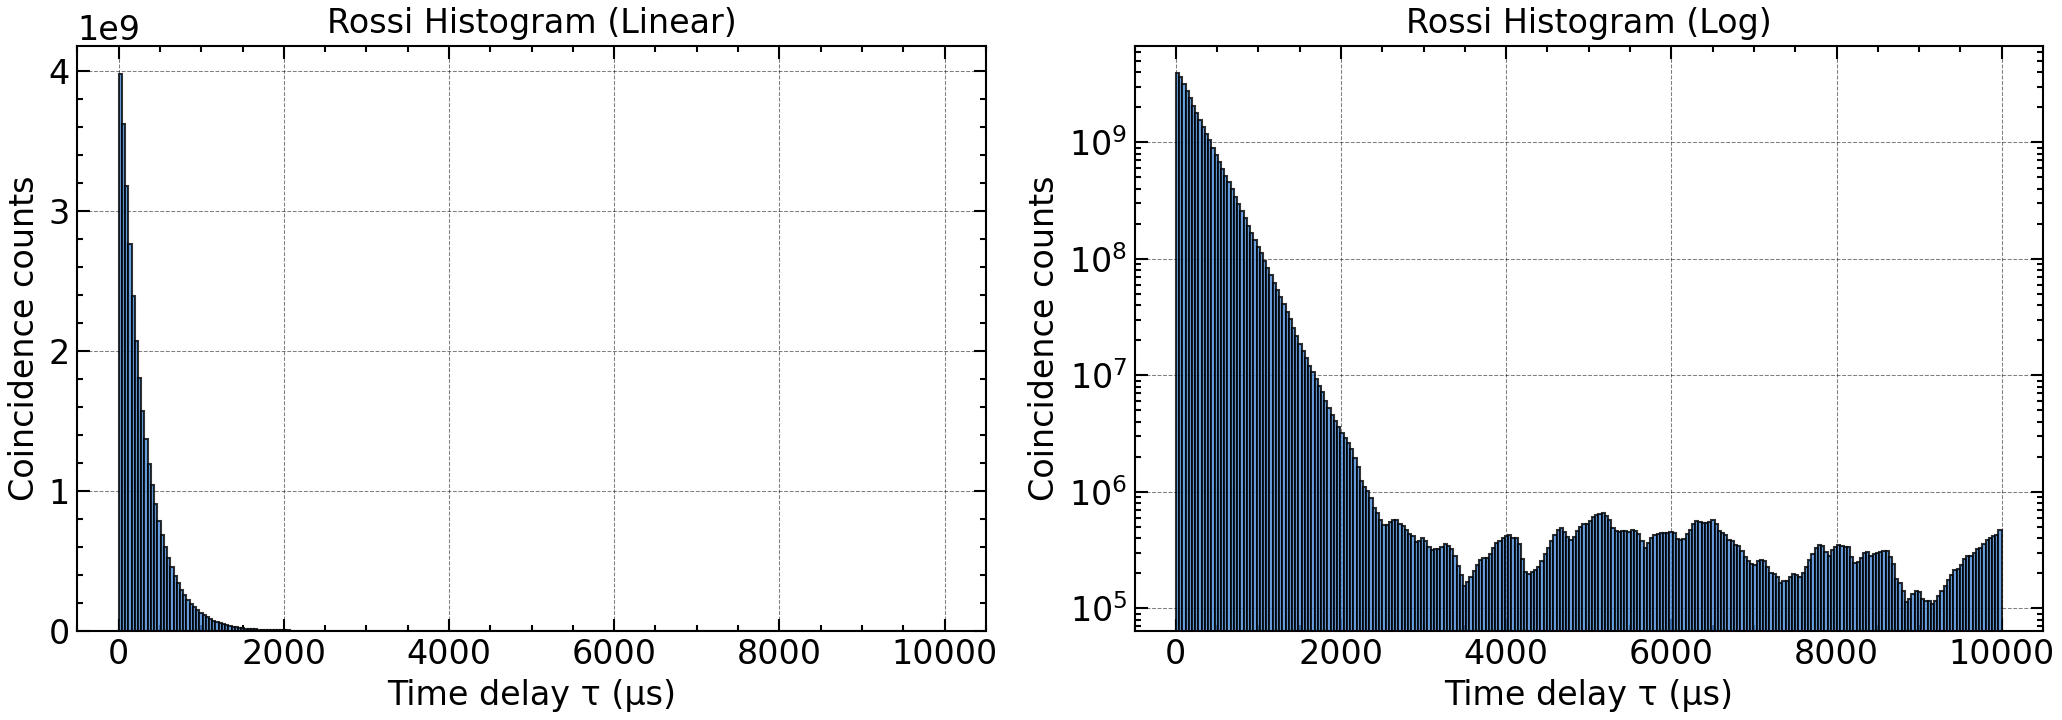

In [35]:
# Plot Rossi histogram: linear and log y-scale side by side
tau_us = bin_centers * 1e6  # convert to microseconds
bin_width_us = tau_us[1] - tau_us[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

for ax, yscale in zip(axes, ["linear", "log"]):
    ax.bar(tau_us, rossi_counts, width=bin_width_us,
           align="center", color="#4A90E2", edgecolor="k", alpha=0.8)
    ax.set_xlabel("Time delay τ (μs)")
    ax.set_ylabel("Coincidence counts")
    ax.set_yscale(yscale)

axes[0].set_title("Rossi Histogram (Linear)")
axes[1].set_title("Rossi Histogram (Log)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
from scipy.optimize import curve_fit

def rossi_alpha_model(tau, A, B, alpha):
    return A + B * np.exp(alpha * tau)

# Initial guess: A ~ mean of tail, B ~ peak - tail, alpha ~ negative
p0 = [counts[-10:].mean(), counts[0] - counts[-10:].mean(), -1e4]
p0 = [0.5e8, 4e8, -10000]

popt, pcov = curve_fit(rossi_alpha_model, bin_centers, rossi_counts, p0=p0)
A_fit, B_fit, alpha_fit = popt


/tmp/ipykernel_3059/2435805949.py:4: RuntimeWarning: overflow encountered in exp
  return A + B * np.exp(alpha * tau)
/tmp/ipykernel_3059/2435805949.py:4: RuntimeWarning: overflow encountered in multiply
  return A + B * np.exp(alpha * tau)


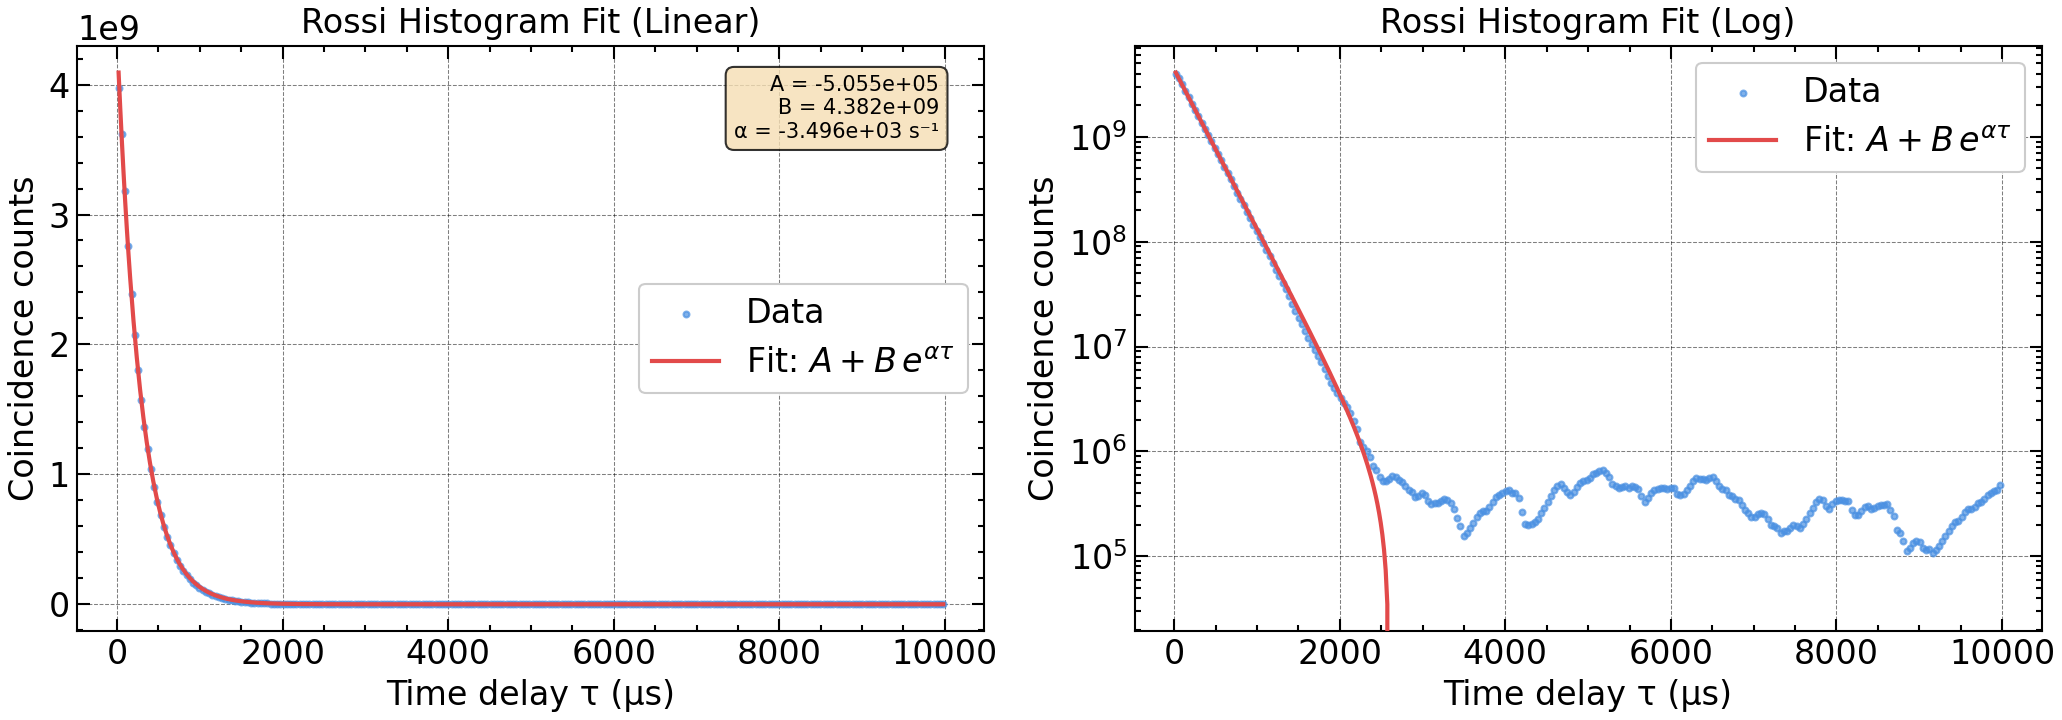

Fitted parameters:
  A (background)     = -5.0547e+05
  B (correlated amp) = 4.3824e+09
  α (decay constant) = -3.4960e+03 s⁻¹


In [37]:
# Plot Rossi histogram with fitted model overlay
tau_us = bin_centers * 1e6  # convert to μs
fit_tau = np.linspace(bin_centers[0], bin_centers[-1], 500)
fit_tau_us = fit_tau * 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

for ax, yscale in zip(axes, ["linear", "log"]):
    ax.scatter(tau_us, rossi_counts, s=8, color="#4A90E2", alpha=0.7, label="Data", zorder=2)
    ax.plot(fit_tau_us, rossi_alpha_model(fit_tau, *popt),
            color="#E24A4A", lw=2, label=r"Fit: $A + B\,e^{\alpha \tau}$", zorder=3)
    ax.set_xlabel("Time delay τ (μs)")
    ax.set_ylabel("Coincidence counts")
    ax.set_yscale(yscale)
    ax.legend(frameon=True)

axes[0].set_title("Rossi Histogram Fit (Linear)")
axes[1].set_title("Rossi Histogram Fit (Log)")

# Annotate fit parameters on the linear panel
param_text = (
    f"A = {A_fit:.3e}\n"
    f"B = {B_fit:.3e}\n"
    f"α = {alpha_fit:.3e} s⁻¹"
)
axes[0].text(
    0.95, 0.95, param_text, transform=axes[0].transAxes,
    ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.8),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_fit.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Fitted parameters:")
print(f"  A (background)     = {A_fit:.4e}")
print(f"  B (correlated amp) = {B_fit:.4e}")
print(f"  α (decay constant) = {alpha_fit:.4e} s⁻¹")

## Summary

This analysis provided insights into:
- **Temporal distribution**: Multi-decade time response captured in log-binned histograms
- **Correlations**: Sibling multiplicity shows parent-progeny detection patterns
- **Validation**: First detection times are physically consistent with geometry
- **Multiplication**: Fission rate quantifies neutron multiplication in the system
- **Rossi alpha**: Coincidence autocorrelation histogram reveals the system's decay constant α